In [60]:
from pathlib import Path
from typing import Any, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
from numpy import ndarray, dtype, float64

INPUT_IMAGE_PATH = Path("data/lfw-deepfunneled/lfw-deepfunneled/Bill_Gates/Bill_Gates_0001.jpg")

In [61]:
# todo
class PortraitMaskTool:
    def __init__(self, image, faces):
        self.image = image
        self.faces = faces
    def generate_mask(self, w_scale=1.0, h_scale=1.0, y_shift_scale=1.0, blur_scale=1.0) -> tuple[Any, Any] | Any:
        height, width = self.image.shape[:2]
        hard_mask = np.zeros((height, width), dtype=np.uint8) #dark pixels
        preview = self.image.copy()
        for (x, y, w, h) in self.faces:
            cv2.rectangle(preview, (x, y), (x + w, y + h), (255, 0, 0), 2)
            center_x = x + w // 2
            center_y = min(height - 1, y + int(h * 0.75 * y_shift_scale)) 
            center = (center_x, center_y)
            
            axis_w = max(1, int(w * 0.90 * w_scale))
            axis_h = max(1, int(h * 1.35 * h_scale))
            axes = (axis_w, axis_h)
            
            cv2.ellipse(hard_mask, center, axes, 0, 0, 360, 255, thickness=cv2.FILLED)

        sigma = max(2, min(height, width) / 90) * blur_scale
        if sigma <= 0:
            return preview,hard_mask
            
        return preview, cv2.GaussianBlur(hard_mask, (0, 0), sigmaX=sigma)
    
def run_GUI(image, mask_tool):
    window_name = "Mask Adjuster (Press 'q' or 'ESC' to Save & Exit)"
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(window_name, 800, 600)
    def on_trackbar(val):
        w_val = cv2.getTrackbarPos('Width', window_name) / 10.0
        h_val = cv2.getTrackbarPos('Height', window_name) / 10.0
        y_val = cv2.getTrackbarPos('Y-Shift', window_name) / 10.0
        b_val = cv2.getTrackbarPos('Blur', window_name) / 10.0


        preview_with_boxes, current_mask = mask_tool.generate_mask(w_scale=w_val, h_scale=h_val, y_shift_scale=y_val, blur_scale=b_val)

        mask_colored = np.zeros_like(image)
        mask_colored[:, :, 2] = current_mask  
        

        overlay_preview = cv2.addWeighted(image, 0.6, mask_colored, 0.4, 0)
        
        raw_mask_bgr = cv2.cvtColor(current_mask, cv2.COLOR_GRAY2BGR)
        combined_view = np.hstack((overlay_preview, raw_mask_bgr))
        
        cv2.imshow(window_name, combined_view)

    cv2.createTrackbar('Width', window_name, 10, 30, on_trackbar)
    cv2.createTrackbar('Height', window_name, 10, 30, on_trackbar)
    cv2.createTrackbar('Y-Shift', window_name, 10, 30, on_trackbar)
    cv2.createTrackbar('Blur', window_name, 10, 50, on_trackbar)

    on_trackbar(0)

    print("Interactive window opened. Adjust sliders, then press 'q' to save and continue.")
    while True:
        key = cv2.waitKey(1) & 0xFF
        if key == 27 or key == ord('q'):  # 27 is ESC
            break

    final_w = cv2.getTrackbarPos('Width', window_name) / 10.0
    final_h = cv2.getTrackbarPos('Height', window_name) / 10.0
    final_y = cv2.getTrackbarPos('Y-Shift', window_name) / 10.0
    final_b = cv2.getTrackbarPos('Blur', window_name) / 10.0
    
    cv2.destroyAllWindows()
    
    return mask_tool.generate_mask(final_w, final_h, final_y, final_b)


In [62]:
image = cv2.imread(str(INPUT_IMAGE_PATH), cv2.IMREAD_COLOR)
if image is None:
    raise FileNotFoundError(f"Could not read: {INPUT_IMAGE_PATH}")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [63]:
cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(cascade_path)
if face_cascade.empty():
    raise RuntimeError("Failed to load haarcascade_frontalface_default.xml")


faces = face_cascade.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=5)

In [ ]:
preview = image.copy()
portraits = PortraitMaskTool(preview, faces)
preview, foreground_mask = portraits.generate_mask()

pre, final_adjusted_mask = run_GUI(image, portraits)

Interactive window opened. Adjust sliders, then press 'q' to save and continue.


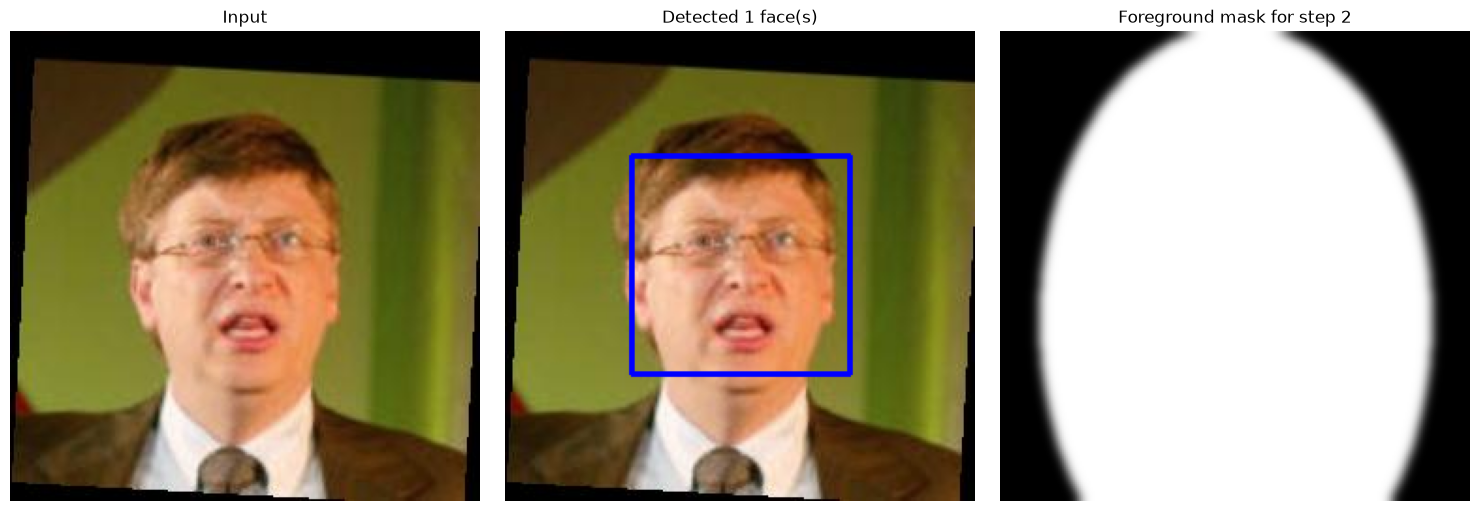

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Input")

axes[1].imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Detected {len(faces)} face(s)")

axes[2].imshow(foreground_mask, cmap="gray")
axes[2].set_title("Foreground mask for step 2")

for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()
